In [1]:
from sklearn.datasets import make_regression

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import RFE

from sklearn.metrics import r2_score, mean_squared_error

In [2]:
# Generate regression dataset with 10 variables
X, y = make_regression(n_samples=1000, n_features=20, n_informative=3, noise=10)

# Convert the data set to a Pandas dataframe
df = pd.DataFrame(X)
df['response'] = y

In [3]:
# Create linear regression object
lr = LinearRegression()

# Define max number of features
max_features = 20

# Define empty arrays to store R2 and MSE values
r2_scores = []
mse_values = []
n_features = range(1, max_features+1)

# Perform RFE and compute R2 and MSE for each number of features
for n in n_features:
    # Define RFE with n variables to select
    rfe = RFE(lr, n_features_to_select=n)

    # Fit RFE
    rfe.fit(X, y)

    # Compute y_pred values
    y_pred = rfe.predict(X)

    # Compute R2 score and MSE
    r2_scores.append(r2_score(y, y_pred))
    mse_values.append(mean_squared_error(y, y_pred))

/Users/caballero/repos/teaching/MSU_REU_ML_course/.venv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/caballero/repos/teaching/MSU_REU_ML_course/.venv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/caballero/repos/teaching/MSU_REU_ML_course/.venv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/caballero/repos/teaching/MSU_REU_ML_course/.venv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/caballero/repos/teaching/MSU_REU_ML_course/.venv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul


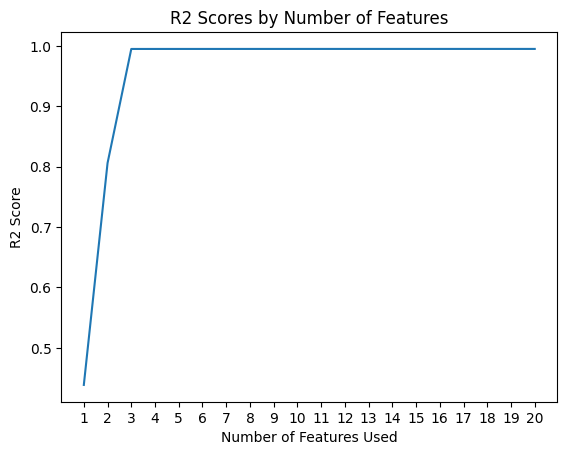

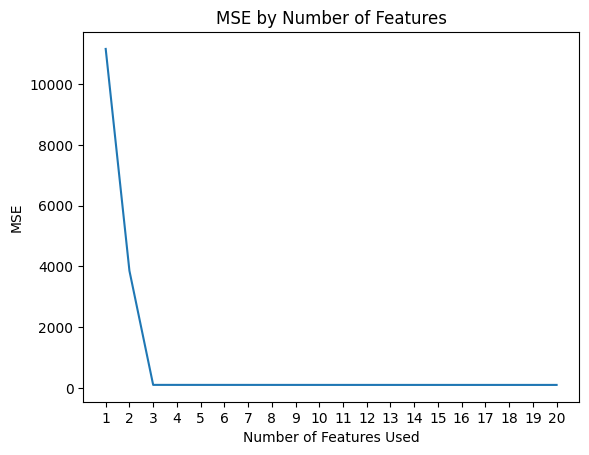

In [4]:
# Plot R2 scores versus number of features used
plt.plot(n_features, r2_scores)
plt.title('R2 Scores by Number of Features')
plt.xlabel('Number of Features Used')
plt.xticks(np.arange(1, max_features+1, 1))
plt.ylabel('R2 Score')
plt.show()

# Plot MSE values versus number of features used
plt.plot(n_features, mse_values)
plt.title('MSE by Number of Features')
plt.xlabel('Number of Features Used')
plt.xticks(np.arange(1, max_features+1, 1))
plt.ylabel('MSE')
plt.show()